In [ ]:
# Робота з таблицями та даними
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Візуалізації
import matplotlib.pyplot as plt
import seaborn as sns

# Статистика
from scipy import stats

# Google BigQuery
from google.cloud import bigquery
from google.colab import auth

In [ ]:
auth.authenticate_user()

**Джерело даних**:

Дані зберігаються в Google BigQuery (навчальний dataset DA).

**Отримання даних:**

Для формування аналітичного датасету використано SQL-запит з обʼєднанням кількох таблиць (session, order, event_params, account_session). Запит виконується безпосередньо з Python за допомогою BigQuery client, результат завантажується у pandas DataFrame.

**Обґрунтування підходу:**

Такий підхід дозволяє автоматизувати процес отримання даних (ETL), уникнути ручного експорту та забезпечує відтворюваність аналізу. Створення view або таблиць у BigQuery обмежене правами доступу в навчальному проєкті.

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
query = """
WITH session_info AS (
SELECT
    s.ga_session_id,
    ab.test,
    ab.test_group
FROM `DA.session` AS s
JOIN `DA.ab_test` AS ab
ON s.ga_session_id = ab.ga_session_id
),

session_cnt AS (
SELECT
    test,
    test_group,
    COUNT(DISTINCT ga_session_id) AS denominator
FROM session_info
GROUP BY test, test_group
),

event_cnt AS (
SELECT
    si.test,
    si.test_group,
    ep.event_name AS metric,
    COUNT(ep.ga_session_id) AS numerator
FROM `DA.event_params` AS ep
JOIN session_info AS si
ON si.ga_session_id = ep.ga_session_id
WHERE ep.event_name IN (
    'add_payment_info',
    'add_shipping_info',
    'begin_checkout'
)
GROUP BY
    si.test,
    si.test_group,
    ep.event_name
),

accounts_cnt AS (
SELECT
    si.test,
    si.test_group,
    'new_accounts' AS metric,
    COUNT(DISTINCT acs.ga_session_id) AS numerator
FROM `DA.account_session` AS acs
JOIN session_info AS si
ON acs.ga_session_id = si.ga_session_id
GROUP BY
    si.test,
    si.test_group
),

metrics_cnt AS (
SELECT
    test,
    test_group,
    metric,
    numerator
FROM event_cnt

UNION ALL

SELECT
    test,
    test_group,
    metric,
    numerator
FROM accounts_cnt
)

SELECT
    m.test,
    m.test_group,
    m.metric,
    m.numerator,
    s.denominator
FROM metrics_cnt AS m
JOIN session_cnt AS s
ON m.test = s.test
AND m.test_group = s.test_group
ORDER BY m.test, m.metric;
"""

In [ ]:
df = client.query(query).to_dataframe()
print(df)

    test  test_group             metric  numerator  denominator
0      1           2   add_payment_info       2229        45193
1      1           1   add_payment_info       1988        45362
2      1           1  add_shipping_info       3034        45362
3      1           2  add_shipping_info       3221        45193
4      1           1     begin_checkout       3784        45362
5      1           2     begin_checkout       4021        45193
6      1           2       new_accounts       3681        45193
7      1           1       new_accounts       3823        45362
8      2           2   add_payment_info       2409        50244
9      2           1   add_payment_info       2344        50637
10     2           1  add_shipping_info       3480        50637
11     2           2  add_shipping_info       3510        50244
12     2           1     begin_checkout       4262        50637
13     2           2     begin_checkout       4313        50244
14     2           1       new_accounts 

#**Перевірка даних**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   test         32 non-null     Int64 
 1   test_group   32 non-null     Int64 
 2   metric       32 non-null     object
 3   numerator    32 non-null     Int64 
 4   denominator  32 non-null     Int64 
dtypes: Int64(4), object(1)
memory usage: 1.5+ KB


#### **1. Перевірка на NULL та аномальні значення**

####Загальна перевірка:

In [ ]:
df["metric"].unique()

array(['add_payment_info', 'add_shipping_info', 'begin_checkout',
       'new_accounts'], dtype=object)

In [ ]:
df["test_group"].unique()

<IntegerArray>
[2, 1]
Length: 2, dtype: Int64

In [ ]:
df["test"].unique()

<IntegerArray>
[1, 2, 3, 4]
Length: 4, dtype: Int64

In [ ]:
print(df.isnull().sum())

test           0
test_group     0
metric         0
numerator      0
denominator    0
dtype: int64


####Візуальна перевірка:

<Axes: >

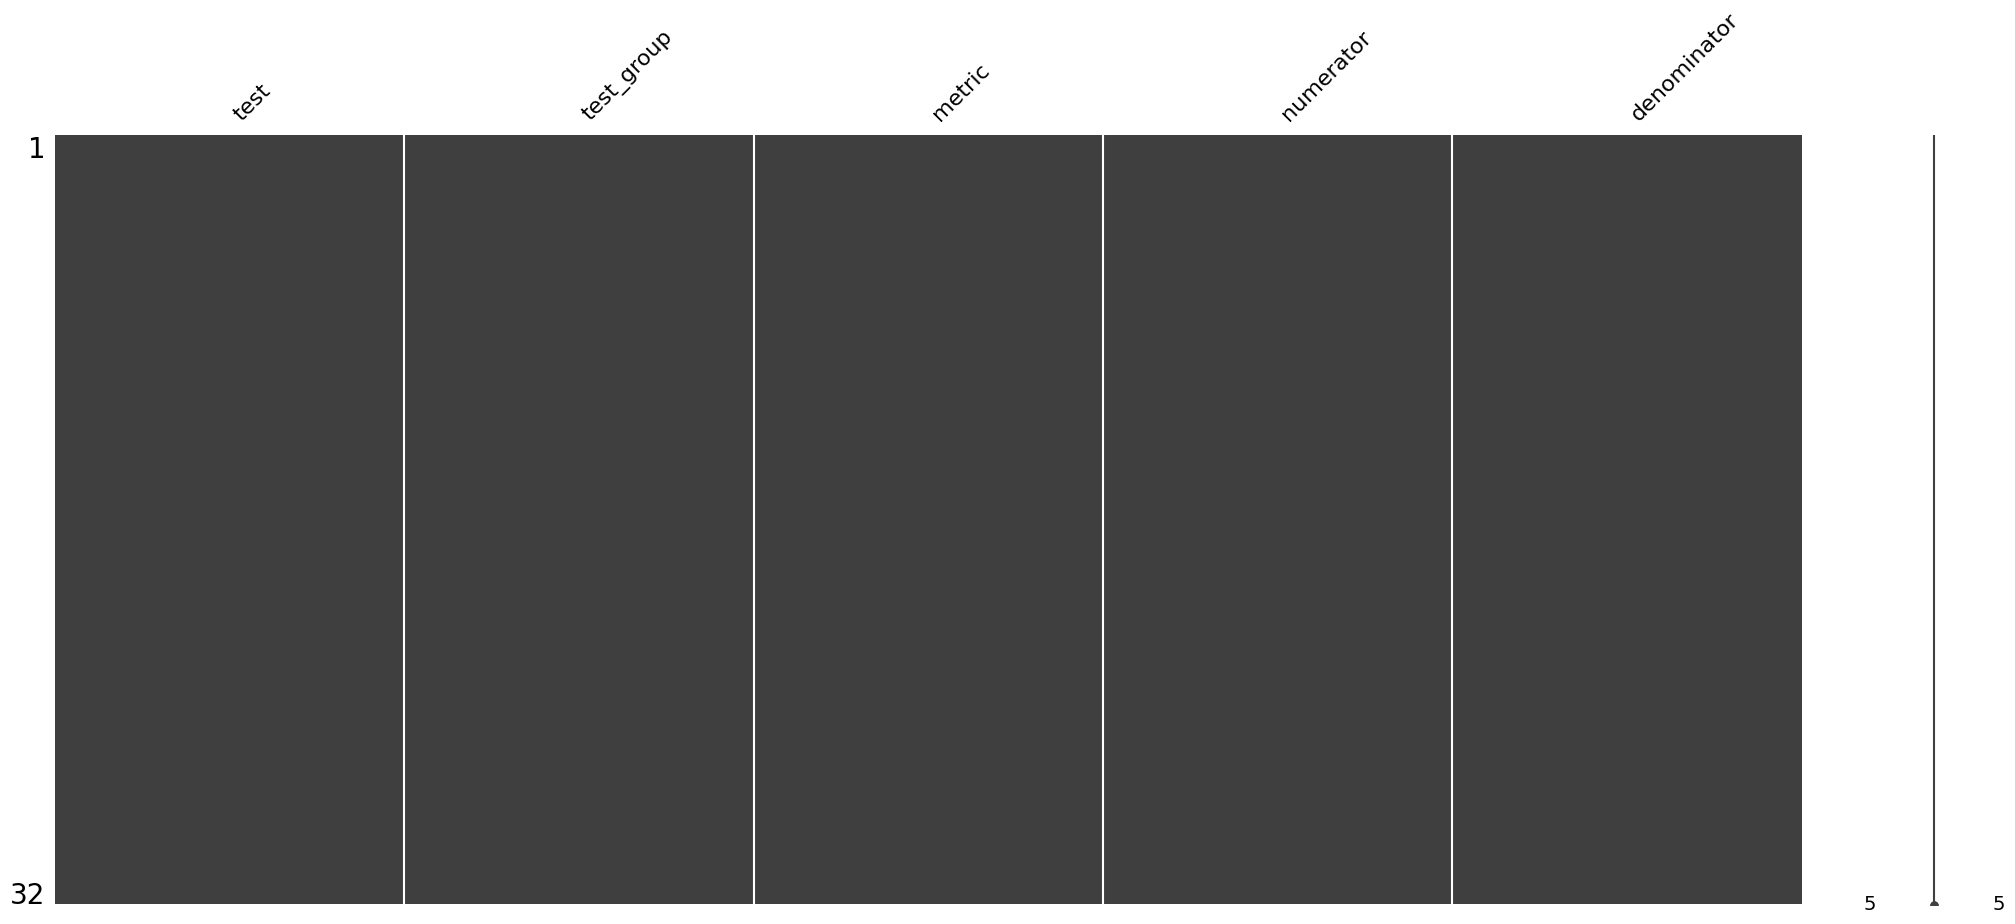

In [ ]:
import missingno as msno
msno.matrix(df)

#### **2. Перевірка на дублікати**

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Знайдено дублікатів: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Дублікати видалено.")

Знайдено дублікатів: 0


#### **3. Логічна перевірка значень**

####Чисельник не може бути більшим за знаменник:

In [ ]:
invalid_rows = df[df['numerator'] > df['denominator']]
if not invalid_rows.empty:
    print("Помилка: Знайдено рядки, де чисельник > знаменник!")

####Відсутність нульових знаменників:

In [ ]:
df[df["denominator"] == 0]

,test,test_group,metric,numerator,denominator


#**Підготовка таблиці для Z-тесту**

####1. Групування

In [ ]:
# Групуємо, щоб отримати загальні суми для кожної групи та метрики
df_total = df.groupby(['test', 'test_group', 'metric'])[['numerator', 'denominator']].sum().reset_index()
print(df_total)

    test  test_group             metric  numerator  denominator
0      1           1   add_payment_info       1988        45362
1      1           1  add_shipping_info       3034        45362
2      1           1     begin_checkout       3784        45362
3      1           1       new_accounts       3823        45362
4      1           2   add_payment_info       2229        45193
5      1           2  add_shipping_info       3221        45193
6      1           2     begin_checkout       4021        45193
7      1           2       new_accounts       3681        45193
8      2           1   add_payment_info       2344        50637
9      2           1  add_shipping_info       3480        50637
10     2           1     begin_checkout       4262        50637
11     2           1       new_accounts       4165        50637
12     2           2   add_payment_info       2409        50244
13     2           2  add_shipping_info       3510        50244
14     2           2     begin_checkout 

####2. Трансформація таблиці (Pivot)


In [ ]:
# Перетворюємо групи Control/Test у стовпчики
df_pivot = df_total.pivot_table(
    index=['test', 'metric'],
    columns='test_group',
    values=['numerator', 'denominator']
).reset_index()

# Робимо назви колонок пласкими, перетворюючи кожен елемент на рядок
df_pivot.columns = ['_'.join(map(str, col)).strip('_') for col in df_pivot.columns.values]
print(df_pivot)

    test             metric  denominator_1  denominator_2  numerator_1  \
0      1   add_payment_info        45362.0        45193.0       1988.0   
1      1  add_shipping_info        45362.0        45193.0       3034.0   
2      1     begin_checkout        45362.0        45193.0       3784.0   
3      1       new_accounts        45362.0        45193.0       3823.0   
4      2   add_payment_info        50637.0        50244.0       2344.0   
5      2  add_shipping_info        50637.0        50244.0       3480.0   
6      2     begin_checkout        50637.0        50244.0       4262.0   
7      2       new_accounts        50637.0        50244.0       4165.0   
8      3   add_payment_info        70047.0        70439.0       3623.0   
9      3  add_shipping_info        70047.0        70439.0       5298.0   
10     3     begin_checkout        70047.0        70439.0       9532.0   
11     3       new_accounts        70047.0        70439.0       5856.0   
12     4   add_payment_info       1050

#  **Розрахунок Z-тесту та P-value**

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Створюємо порожні списки для результатів
z_stats = []
p_values = []

# Цикл по кожному рядку отриманої таблиці
for index, row in df_pivot.iterrows():
    # Формуємо дані для тесту: порівнюємо групу 2 з групою 1
    counts = [row['numerator_2'], row['numerator_1']]
    nobs = [row['denominator_2'], row['denominator_1']]

    # Виконуємо Z-тест
    z_stat, p_val = proportions_ztest(counts, nobs)

    # Додаємо результати у списки
    z_stats.append(z_stat)
    p_values.append(p_val)

# Додаємо нові колонки в таблицю
df_pivot['z_stat'] = z_stats
df_pivot['p_value'] = p_values

#### 1.Додавання конверсій та значущості

In [ ]:
# Розрахунок конверсій
df_pivot['conversion_raw_control'] = df_pivot['numerator_1'] / df_pivot['denominator_1']
df_pivot['conversion_raw_test'] = df_pivot['numerator_2'] / df_pivot['denominator_2']

# Розрахунок відносної зміни у % (Metric Change)
df_pivot['metric_change_pct'] = (df_pivot['conversion_raw_test'] / df_pivot['conversion_raw_control'] - 1) * 100

# Визначення значущості (за стандартним порогом 0.05)
df_pivot['significant'] = df_pivot['p_value'] < 0.05

df_pivot['significant'] = df_pivot['significant'].astype(str)

# Виводимо результат
display(df_pivot)

,test,metric,numerator_2,denominator_2,conversion_raw_test,numerator_1,denominator_1,conversion_raw_control,metric_change_pct,z_stat,p_value,significant
0,1,add_payment_info,2229.0,45193.0,0.049322,1988.0,45362.0,0.043825,12.542021,3.924884,0.000087,True
1,1,add_shipping_info,3221.0,45193.0,0.071272,3034.0,45362.0,0.066884,6.560481,2.603571,0.009226,True
2,1,begin_checkout,4021.0,45193.0,0.088974,3784.0,45362.0,0.083418,6.660587,2.978783,0.002894,True
3,1,new_accounts,3681.0,45193.0,0.081451,3823.0,45362.0,0.084278,-3.354299,-1.542883,0.122859,False
4,2,add_payment_info,2409.0,50244.0,0.047946,2344.0,50637.0,0.04629,3.576911,1.240994,0.214608,False
5,2,add_shipping_info,3510.0,50244.0,0.069859,3480.0,50637.0,0.068724,1.650995,0.709557,0.477979,False
6,2,begin_checkout,4313.0,50244.0,0.085841,4262.0,50637.0,0.084168,1.988164,0.952898,0.340642,False
7,2,new_accounts,4184.0,50244.0,0.083274,4165.0,50637.0,0.082252,1.241934,0.588793,0.556000,False
8,3,add_payment_info,3697.0,70439.0,0.052485,3623.0,70047.0,0.051722,1.47463,0.643172,0.520112,False
9,3,add_shipping_info,5188.0,70439.0,0.073652,5298.0,70047.0,0.075635,-2.621211,-1.413727,0.157442,False


In [ ]:
print(df_pivot.columns)

Index(['test', 'metric', 'denominator_1', 'denominator_2', 'numerator_1',
       'numerator_2', 'z_stat', 'p_value', 'conversion_raw_control',
       'conversion_raw_test', 'metric_change_pct', 'significant'],
      dtype='object')


In [ ]:
df_pivot = df_pivot[
    [
        'test',
        'metric',
        'numerator_2',
        'denominator_2',
        'conversion_raw_test',
        'numerator_1',
        'denominator_1',
        'conversion_raw_control',
        'metric_change_pct',
        'z_stat',
        'p_value',
        'significant'
    ]
]
# Виводимо результат
display(df_pivot)

,test,metric,numerator_2,denominator_2,conversion_raw_test,numerator_1,denominator_1,conversion_raw_control,metric_change_pct,z_stat,p_value,significant
0,1,add_payment_info,2229.0,45193.0,0.049322,1988.0,45362.0,0.043825,12.542021,3.924884,0.000087,True
1,1,add_shipping_info,3221.0,45193.0,0.071272,3034.0,45362.0,0.066884,6.560481,2.603571,0.009226,True
2,1,begin_checkout,4021.0,45193.0,0.088974,3784.0,45362.0,0.083418,6.660587,2.978783,0.002894,True
3,1,new_accounts,3681.0,45193.0,0.081451,3823.0,45362.0,0.084278,-3.354299,-1.542883,0.122859,False
4,2,add_payment_info,2409.0,50244.0,0.047946,2344.0,50637.0,0.04629,3.576911,1.240994,0.214608,False
5,2,add_shipping_info,3510.0,50244.0,0.069859,3480.0,50637.0,0.068724,1.650995,0.709557,0.477979,False
6,2,begin_checkout,4313.0,50244.0,0.085841,4262.0,50637.0,0.084168,1.988164,0.952898,0.340642,False
7,2,new_accounts,4184.0,50244.0,0.083274,4165.0,50637.0,0.082252,1.241934,0.588793,0.556000,False
8,3,add_payment_info,3697.0,70439.0,0.052485,3623.0,70047.0,0.051722,1.47463,0.643172,0.520112,False
9,3,add_shipping_info,5188.0,70439.0,0.073652,5298.0,70047.0,0.075635,-2.621211,-1.413727,0.157442,False


###Візуалізація:

/tmp/ipython-input-96570915.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='metric', y='metric_change_pct', data=test_1_data, palette='viridis')


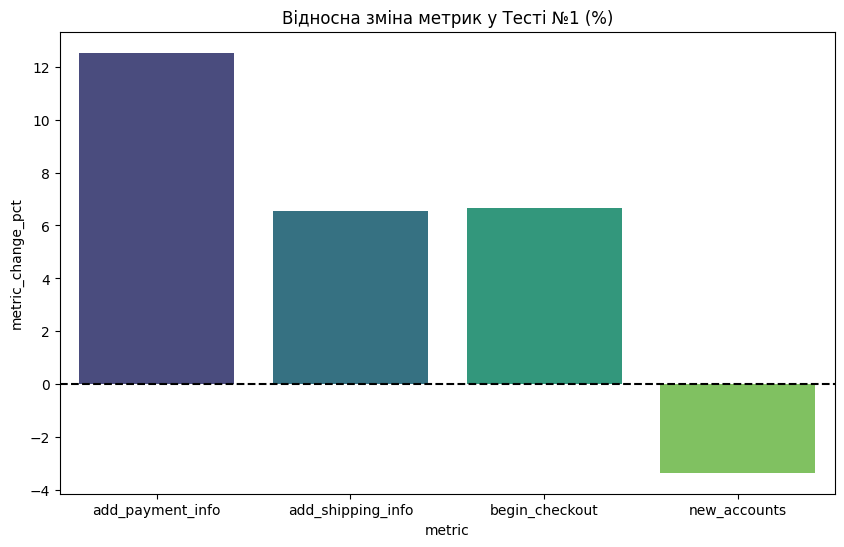

In [ ]:
# Фільтруємо дані лише для Тесту 1, щоб побачити успішні метрики
test_1_data = df_pivot[df_pivot['test'] == 1]

plt.figure(figsize=(10, 6))
sns.barplot(x='metric', y='metric_change_pct', data=test_1_data, palette='viridis')
plt.title('Відносна зміна метрик у Тесті №1 (%)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

###Основні спостереження з графіка:

1. **Позитивна динаміка** на верхніх етапах воронки

*add_payment_info*:  

 Ця метрика показала найбільший приріст — +12,54%. Це свідчить про те, що зміни в Тесті №1 значно спростили або мотивували користувачів додавати платіжні дані.

*add_shipping_info* та *begin_checkout*:

Обидві метрики продемонстрували майже однакове зростання — приблизно на +6,5% (6,56% та 6,66% відповідно). Це вказує на стабільний позитивний ефект змін на шляху до оформлення замовлення.

2. **Негативний вплив** на реєстрації
*new_accounts*:

 Єдина метрика, що пішла в «мінус», показавши падіння на -3,35%.

**Важливий нюанс:**

Хоча на графіку падіння виглядає суттєвим, статистичні розрахунки показують p-value = 0.122. Це означає, що падіння в реєстраціях не є статистично значущим (significant = False) і може бути результатом випадкових коливань.

3. **Статистична підтвердженість (Z-test)**

Для всіх трьох позитивних метрик (add_payment, add_shipping, begin_checkout) p-value значно менше 0,05 (0.000087, 0.009 та 0.002 відповідно).

Це означає, що позитивні зміни не є випадковими. Маємо достатньо доказів, щоб стверджувати: зміни в Тесті №1 дійсно покращують конверсію на цих етапах.

In [ ]:
df_pivot.to_csv('ab_test_results.csv', index=False)

Незважаючи на виявлену статистичну значущість та позитивний приріст у Тесті №1, загальні цифри можуть приховувати важливі деталі. Для того, щоб зрозуміти, чи є цей успіх рівномірним для всієї аудиторії, або ж він зумовлений конкретними групами користувачів,переходимо до поглибленого аналізу в розрізі сегментів

#**Поглиблений аналіз результатів A/B тестування у розрізі користувацьких сегментів**

In [ ]:
segment_sql = """
WITH session_info AS (
    SELECT
        s.ga_session_id,
        sp.continent,
        sp.device,
        sp.channel,
        sp.operating_system,
        ab.test,
        ab.test_group
    FROM `DA.session` s
    JOIN `DA.ab_test` ab
        ON s.ga_session_id = ab.ga_session_id
    JOIN `DA.session_params` sp
        ON s.ga_session_id = sp.ga_session_id
),

session_cnt AS (
    SELECT
        test,
        test_group,
        continent,
        device,
        channel,
        operating_system,
        COUNT(DISTINCT ga_session_id) AS denominator
    FROM session_info
    GROUP BY test, test_group,
             continent, device, channel, operating_system
),

event_cnt AS (
    SELECT
        si.test,
        si.test_group,
        si.continent,
        si.device,
        si.channel,
        si.operating_system,
        ep.event_name AS metric,
        COUNT(DISTINCT ep.ga_session_id) AS numerator
    FROM `DA.event_params` ep
    JOIN session_info si
        ON ep.ga_session_id = si.ga_session_id
    WHERE ep.event_name IN (
        'add_payment_info',
        'add_shipping_info',
        'begin_checkout'
    )
    GROUP BY si.test, si.test_group,
             si.continent, si.device, si.channel, si.operating_system,
             ep.event_name
),

accounts_cnt AS (
    SELECT
        si.test,
        si.test_group,
        si.continent,
        si.device,
        si.channel,
        si.operating_system,
        'new_accounts' AS metric,
        COUNT(DISTINCT acs.ga_session_id) AS numerator
    FROM `DA.account_session` acs
    JOIN session_info si
        ON acs.ga_session_id = si.ga_session_id
    GROUP BY si.test, si.test_group,
             si.continent, si.device, si.channel, si.operating_system
),

metrics_cnt AS (
    SELECT * FROM event_cnt
    UNION ALL
    SELECT * FROM accounts_cnt
)

SELECT
    m.test,
    m.test_group,
    m.metric,
    m.continent,
    m.device,
    m.channel,
    m.operating_system,
    m.numerator,
    s.denominator
FROM metrics_cnt m
JOIN session_cnt s
    ON m.test = s.test
   AND m.test_group = s.test_group
   AND m.continent = s.continent
   AND m.device = s.device
   AND m.channel = s.channel
   AND m.operating_system = s.operating_system
ORDER BY
    m.test,
    m.test_group,
    m.metric;
"""


In [ ]:
df_segment = client.query(segment_sql).to_dataframe()
print(df_segment)

      test  test_group            metric continent   device         channel  \
0        1           1  add_payment_info  Americas   mobile       Undefined   
1        1           1  add_payment_info      Asia   mobile   Social Search   
2        1           1  add_payment_info      Asia   mobile   Social Search   
3        1           1  add_payment_info  Americas   mobile          Direct   
4        1           1  add_payment_info      Asia   tablet   Social Search   
...    ...         ...               ...       ...      ...             ...   
5328     4           2      new_accounts    Europe   mobile   Social Search   
5329     4           2      new_accounts    Africa  desktop   Social Search   
5330     4           2      new_accounts  Americas  desktop  Organic Search   
5331     4           2      new_accounts  Americas  desktop       Undefined   
5332     4           2      new_accounts    Africa  desktop     Paid Search   

     operating_system  numerator  denominator  
0  

#**Перевірка даних**

In [ ]:
df_segment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5333 entries, 0 to 5332
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   test              5333 non-null   Int64 
 1   test_group        5333 non-null   Int64 
 2   metric            5333 non-null   object
 3   continent         5333 non-null   object
 4   device            5333 non-null   object
 5   channel           5333 non-null   object
 6   operating_system  5333 non-null   object
 7   numerator         5333 non-null   Int64 
 8   denominator       5333 non-null   Int64 
dtypes: Int64(4), object(5)
memory usage: 395.9+ KB


#### **1. Перевірка на NULL та аномальні значення**

In [ ]:
df_segment["metric"].unique()

array(['add_payment_info', 'add_shipping_info', 'begin_checkout',
       'new_accounts'], dtype=object)

In [ ]:
df_segment["test_group"].unique()

<IntegerArray>
[1, 2]
Length: 2, dtype: Int64

In [ ]:
df_segment["test"].unique()

<IntegerArray>
[1, 2, 3, 4]
Length: 4, dtype: Int64

In [ ]:
print(df_segment.isnull().sum())

test                0
test_group          0
metric              0
continent           0
device              0
channel             0
operating_system    0
numerator           0
denominator         0
dtype: int64


####Візуальна перевірка:

<Axes: >

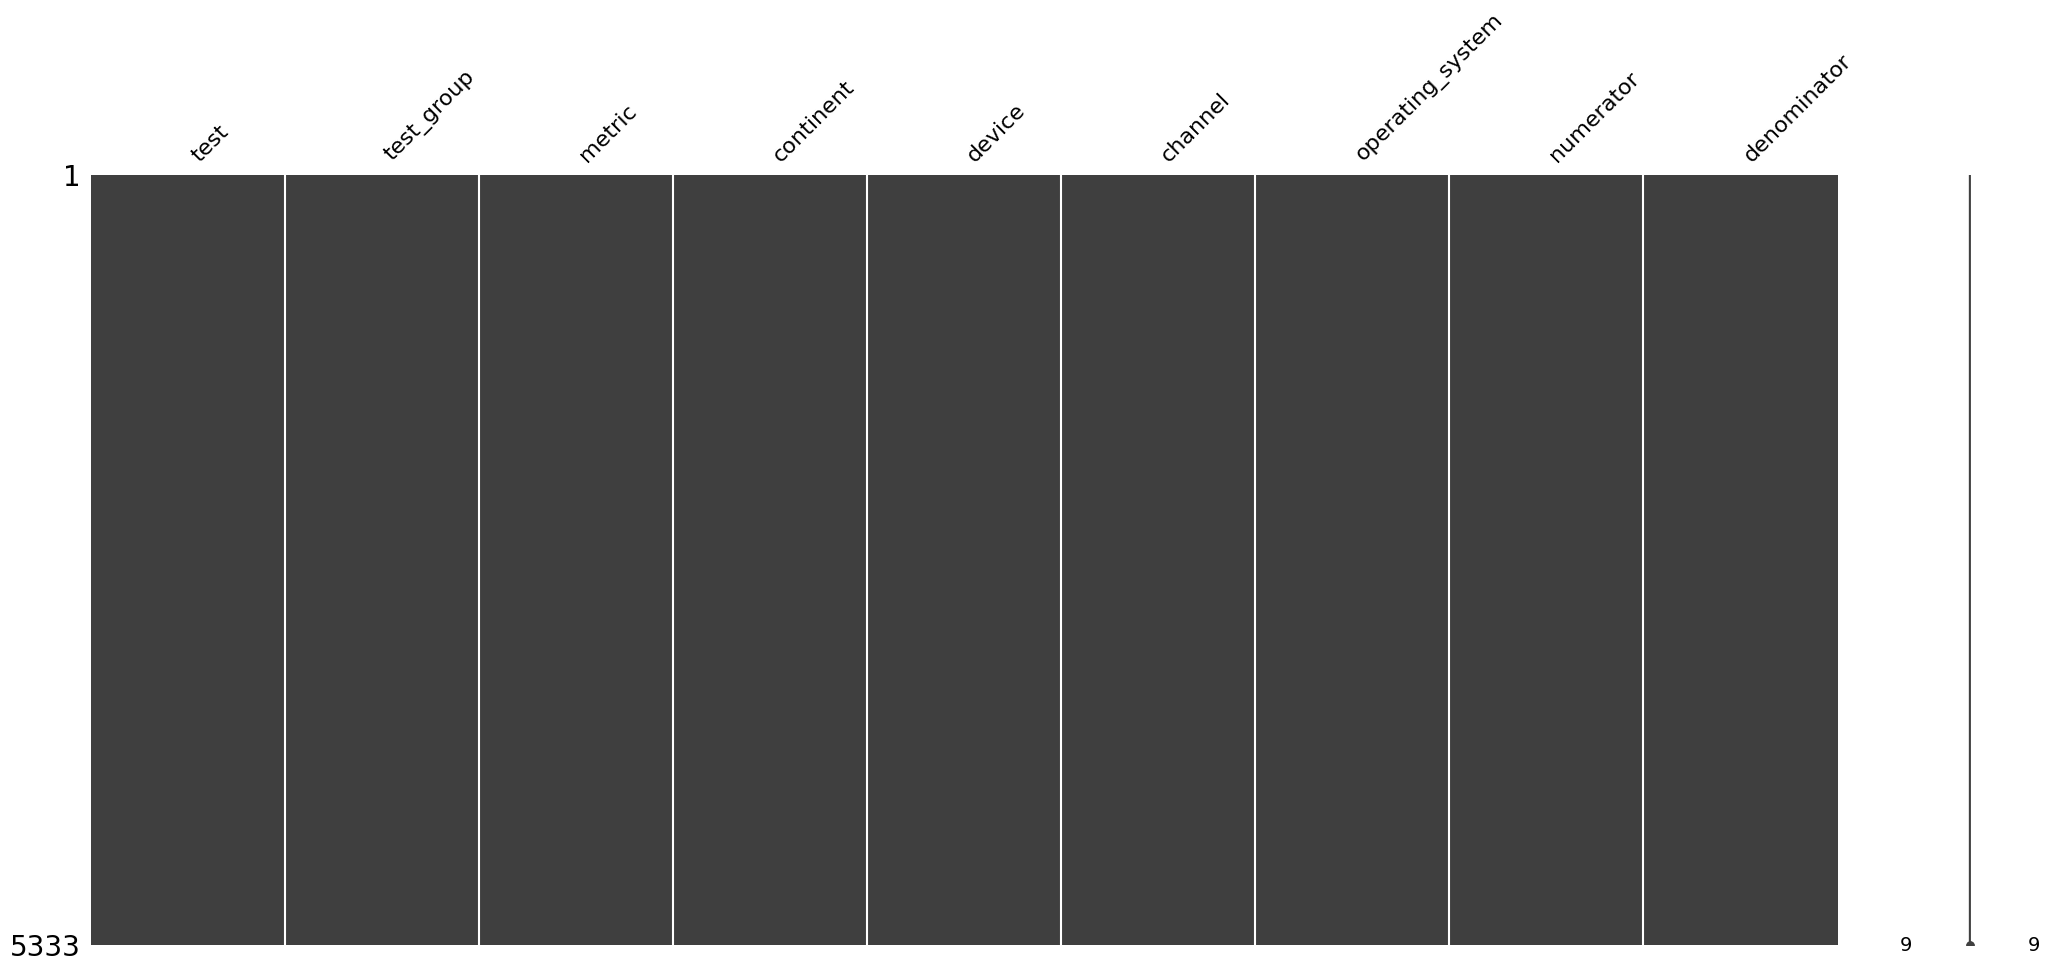

In [ ]:
msno.matrix(df_segment)

#### **2. Перевірка на дублікати**

In [ ]:
duplicate_count = df_segment.duplicated().sum()
print(f"Знайдено дублікатів: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()

Знайдено дублікатів: 0


#### **3. Логічна перевірка значень**

####Чисельник не може бути більшим за знаменник:

In [ ]:
invalid_rows = df_segment[df_segment['numerator'] > df_segment['denominator']]
if not invalid_rows.empty:
    print("Помилка: Знайдено рядки, де чисельник > знаменник!")


####Відсутність нульових знаменників:

In [ ]:
df_segment[df_segment["denominator"] == 0]

,test,test_group,metric,continent,device,channel,operating_system,numerator,denominator


#  **Розрахунок Z-тесту та P-value**

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Сегменти для аналізу
segments = ['continent', 'device', 'channel', 'operating_system']

# Метрики за ТЗ
required_metrics = [
    'add_payment_info',
    'add_shipping_info',
    'begin_checkout',
    'new_accounts'
]

# Словник для результатів
all_results = {}

for segment in segments:

    #  Групування
    df_seg = (
        df_segment
        .groupby(['test', 'metric', segment, 'test_group'])[['numerator', 'denominator']]
        .sum()
        .reset_index()
    )

    #  Pivot (розгортаємо групи в колонки)
    df_pivot_seg = (
        df_seg
        .pivot_table(
            index=['test', 'metric', segment],
            columns='test_group',
            values=['numerator', 'denominator']
        )
        .reset_index()
    )

    #  Вирівнюємо назви колонок
    df_pivot_seg.columns = [
        'test',
        'metric',
        segment,
        'denominator_1',
        'denominator_2',
        'numerator_1',
        'numerator_2'
    ]

    #  Фільтр метрик
    df_pivot_seg = df_pivot_seg[
        df_pivot_seg['metric'].isin(required_metrics)
    ]

    #  Z-test
    z_stats = []
    p_values = []

    for _, row in df_pivot_seg.iterrows():
        counts = [row['numerator_2'], row['numerator_1']]
        nobs   = [row['denominator_2'], row['denominator_1']]
        z, p = proportions_ztest(counts, nobs)
        z_stats.append(z)
        p_values.append(p)

    df_pivot_seg['z_stat'] = z_stats
    df_pivot_seg['p_value'] = p_values
    df_pivot_seg['significant'] = df_pivot_seg['p_value'] < 0.05

    #  Conversion
    df_pivot_seg['conversion_1'] = (
        df_pivot_seg['numerator_1'] /
        df_pivot_seg['denominator_1']
    )

    df_pivot_seg['conversion_2'] = (
        df_pivot_seg['numerator_2'] /
        df_pivot_seg['denominator_2']
    )

    #  Uplift
    df_pivot_seg['metric_change_pct'] = (
        (df_pivot_seg['conversion_2'] - df_pivot_seg['conversion_1']) /
        df_pivot_seg['conversion_1']
    )

    #  Упорядковуємо колонки
    df_pivot_seg = df_pivot_seg[
        [
            'test',
            'metric',
            segment,
            'numerator_2',
            'denominator_2',
            'conversion_2',
            'numerator_1',
            'denominator_1',
            'conversion_1',
            'metric_change_pct',
            'z_stat',
            'p_value',
            'significant'
        ]
    ]

    #  Зберігаємо
    all_results[segment] = df_pivot_seg


print(" Сегментний статистичний аналіз завершено!")

 Сегментний статистичний аналіз завершено!


####Об'єднання сегментів:

In [ ]:
combined_segments = []

for segment_name, segment_df in all_results.items():

    temp_df = segment_df.copy()

    # Додаємо тип сегмента
    temp_df["segment_type"] = segment_name

    # Додаємо значення сегмента
    temp_df["segment_value"] = temp_df[segment_name]

    # Видаляємо оригінальну колонку сегмента
    temp_df = temp_df.drop(columns=[segment_name])

    combined_segments.append(temp_df)

# Об’єднуємо всі сегменти
df_all_segments_combined = pd.concat(combined_segments, ignore_index=True)

print(" Усі сегменти об’єднані")
print(df_all_segments_combined.shape)

 Усі сегменти об’єднані
(320, 14)


###Експорт файлів:

### **CSV**

In [ ]:
df_pivot.to_csv("AB_Test_Total.csv", index=False)

from google.colab import files
files.download("AB_Test_Total.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df_pivot.columns)

Index(['test', 'metric', 'numerator_2', 'denominator_2', 'conversion_raw_test',
       'numerator_1', 'denominator_1', 'conversion_raw_control',
       'metric_change_pct', 'z_stat', 'p_value', 'significant'],
      dtype='object')


### **Excel**

In [ ]:
file_path = "AB_Test_Results_Final.xlsx"

df_pivot['significant'] = df_pivot['p_value'] < 0.05

df_pivot['significant'] = df_pivot['significant'].map({True: 'TRUE', False: 'FALSE'})


if 'p_value' in df_all_segments_combined.columns:
    df_all_segments_combined['significant'] = df_all_segments_combined['p_value'] < 0.05
df_all_segments_combined['significant'] = df_all_segments_combined['significant'].map({True: 'TRUE', False: 'FALSE'})

# Записуємо файл
with pd.ExcelWriter(file_path) as writer:
    df_pivot.to_excel(writer, sheet_name="Total", index=False)
    df_all_segments_combined.to_excel(writer, sheet_name="All_Segments_Combined", index=False)

    from google.colab import files
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**Опис етапів та висновки**
1. **Підготовка даних (SQL)**

Першим етапом було формування аналітичного датасету з сирих логів бази даних.

Агрегація подій: Написання запитів для розрахунку кількості унікальних користувачів (denominators) та цільових дій (numerators) для кожної групи.

Групування за сегментами: Дані були сегментовані за географією (continent), пристроями та операційними системами для подальшого глибокого аналізу.


2. **Статистичний аналіз (Python)**

Для автоматизації розрахунків та перевірки надійності результатів використано Python.

Перевірка гіпотез: Розрахунок Z-статистики та p-value для визначення статистичної значущості змін у конверсії.

Розрахунок Lift: Визначення відсоткового приросту тестової групи відносно контрольної для кожної метрики.

Data Transformation: Проведення операції Pivot для перетворення структури даних у формат, придатний для візуалізації розподілу трафіку.

🔗**CSV-файл з результатами статистичних розрахунків:**
(https://drive.google.com/file/d/1V_Ufc5lmhnRv4pjL_O9CcOvbEPBIC71t/view?usp=sharing)

3. **Сегментний аналіз**

Для поглибленого аналізу результати були розраховані у розрізі:

Континентів

Пристроїв

Каналів трафіку

Операційних систем

Було створено об’єднану таблицю All_Segments_Combined, що дозволяє:

Динамічно фільтрувати сегменти в Tableau

Аналізувати uplift по кожному сегменту

Виявляти неоднорідність впливу тесту.

🔗**Excel-файл з результатами розрахунків та сегментним аналізом:**
(https://docs.google.com/spreadsheets/d/1qdJDfsjK03Z8kN_ArZdn-y4MhNZBpc90/edit?usp=sharing&ouid=108067078050385075647&rtpof=true&sd=true)

4. **Візуалізація та інсайти (Tableau)**

Дашборд розділений на два логічні рівні: стратегічний огляд та детальний сегментарний аналіз.

**Сторінка 1: Головні метрики та статзначущість**

Ця сторінка фокусується на загальних результатах експерименту для прийняття швидких рішень.

Аналіз ключових етапів: Візуалізація відсоткової зміни конверсії (Metric Change %) та відповідних p-value для кожного кроку воронки.

Статистична валідація: Детальна таблиця з розрахунками Z-score та довірчих рівнів.

Технічний блок: Опис методології аналізу (Python/Google Colab), використання Z-тесту для частотних ймовірностей та посилання на відкритий код.

**Сторінка 2: Сегментарний аналіз (Deep Dive)**
Призначена для пошуку аномалій та точкових інсайтів у розрізі географії та технологій.

Контроль якості (Balanced Traffic Split): Перевірка рівномірності розподілу трафіку, що підтверджує відсутність SRM-помилки.

Поведінкова воронка: Порівняння лінійних графіків конверсії Control vs Variant для візуального відстеження розриву між групами.

Теплова карта підйому (Conversion Lift): Матриця, що підсвічує найбільш успішні та проблемні зони.

Статус значущості за сегментами: Точковий графік, що дозволяє швидко відокремити реально працюючі зміни (TRUE) від випадкових коливань.

🔗 **Посилання на Tableau Dashboard:**
(https://public.tableau.com/views/Book9_17721025986300/E-commerceABTestStatisticalSignificanceSegmentAnalysis?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

###**Основні висновки:**

Розподіл трафіку між групами був збалансований (~50/50), що забезпечує коректність статистичного порівняння.

Тест показав статистично значущі покращення для окремих метрик середини воронки (наприклад, add_shipping_info, begin_checkout).

Для purchase_rate у загальному підсумку статистично значущого ефекту не виявлено.

Сегментний аналіз показав неоднорідність результатів:


*   Деякі сегменти демонструють позитивний uplift.
*   В окремих сегментах спостерігається негативний ефект.
*   Частина сегментів має статистично значущі результати.


Це свідчить про те, що вплив тесту залежить від характеристик користувачів.

###**Підсумковий висновок**

A/B-тест продемонстрував частковий позитивний вплив на ключові етапи воронки, однак ефект є неоднорідним залежно від сегмента.

**Рекомендації:**


*   Розглянути поступовий rollout у сегментах з позитивним uplift.
*   Додатково дослідити сегменти з негативним впливом.
*   Продовжити моніторинг purchase_rate для стабільності результатів.